In [31]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



# Chuẩn hóa phần môi trường và đường dẫn

In [32]:
import os, json
import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data", "raw", "electricity.csv")
ARTIFACT_DIR = os.path.join(BASE_DIR, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Chuẩn bị dữ liệu





1.upload dữ liệu

In [33]:
df = pd.read_csv("../data/sample/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,12/31/2002 1:00,26498
1,12/31/2002 2:00,25147
2,12/31/2002 3:00,24574
3,12/31/2002 4:00,24393
4,12/31/2002 5:00,24860


Xem cấu trúc dữ liệu

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Datetime  145366 non-null  object
 1   PJME_MW   145366 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.2+ MB


Chuyển cột thời gian sang datetime + sắp xếp

In [35]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
df.head(20)

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393
1,2002-01-01 02:00:00,29265
2,2002-01-01 03:00:00,28357
3,2002-01-01 04:00:00,27899
4,2002-01-01 05:00:00,28057
5,2002-01-01 06:00:00,28654
6,2002-01-01 07:00:00,29308
7,2002-01-01 08:00:00,29595
8,2002-01-01 09:00:00,29943
9,2002-01-01 10:00:00,30692


2. Xử lý dữ liệu

Kiểm tra missing

In [36]:
df.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

Kiểm tra giá trị bất thường

In [37]:
df.describe()

,Datetime,PJME_MW
count,145366,145366.000000
mean,2010-04-18 03:25:25.999201536,32080.222831
min,2002-01-01 01:00:00,14544.000000
25%,2006-02-23 14:15:00,27573.000000
50%,2010-04-18 04:30:00,31421.000000
75%,2014-06-10 18:45:00,35650.000000
max,2018-08-03 00:00:00,62009.000000
std,NaN,6464.012166


Đổi tên cột theo chuẩn chung (timestamp, load)


In [38]:
df = df.rename(columns={"Datetime":"timestamp", "PJME_MW":"load"})
df.head()


,timestamp,load
0,2002-01-01 01:00:00,30393
1,2002-01-01 02:00:00,29265
2,2002-01-01 03:00:00,28357
3,2002-01-01 04:00:00,27899
4,2002-01-01 05:00:00,28057


Kiểm tra khoảng thời gian dữ liệu

In [39]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Bắt đầu:", df["timestamp"].min())
print("Kết thúc:", df["timestamp"].max())
print("Năm bắt đầu:", df["timestamp"].min().year)
print("Năm kết thúc:", df["timestamp"].max().year)

Bắt đầu: 2002-01-01 01:00:00
Kết thúc: 2018-08-03 00:00:00
Năm bắt đầu: 2002
Năm kết thúc: 2018


Vẽ biểu đồ tổng quan

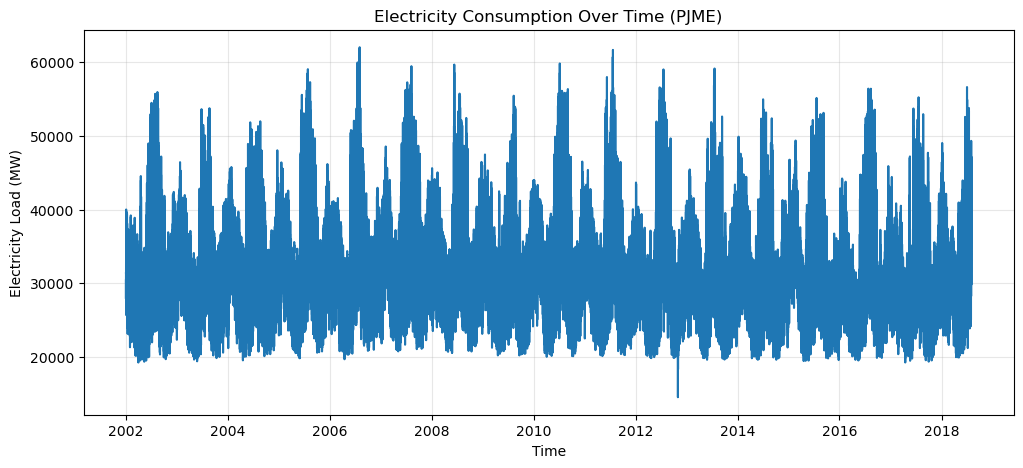

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["timestamp"], df["load"])
plt.title("Electricity Consumption Over Time (PJME)")
plt.xlabel("Time")
plt.ylabel("Electricity Load (MW)")
plt.grid(True, alpha=0.3)
plt.show()

Nhận xét: Dữ liệu thể hiện tính chu kỳ rõ theo giờ/ngày/tuần. Biên độ dao động lớn giữa giờ cao điểm và thấp điểm, phù hợp cho bài toán dự báo nhu cầu tiêu thụ điện năng.

# MÔ HÌNH XGBOOST

1. Chuẩn bị dữ liệu cho XGBoost (Feature Engineering)

Tạo feature theo thời gian

In [41]:
import numpy as np

d = df.copy()

d["hour"] = d["timestamp"].dt.hour
d["dayofweek"] = d["timestamp"].dt.dayofweek
d["month"] = d["timestamp"].dt.month
d["year"] = d["timestamp"].dt.year
d["is_weekend"] = (d["dayofweek"] >= 5).astype(int)

# cyclical encoding (giúp model hiểu chu kỳ)
d["hour_sin"] = np.sin(2*np.pi*d["hour"]/24)
d["hour_cos"] = np.cos(2*np.pi*d["hour"]/24)
d["dow_sin"]  = np.sin(2*np.pi*d["dayofweek"]/7)
d["dow_cos"]  = np.cos(2*np.pi*d["dayofweek"]/7)

Tạo biến trễ (lag) theo giờ

In [42]:
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]  # 168 = 7 ngày

for lag in lags:
    d[f"lag_{lag}"] = d["load"].shift(lag)

d = d.dropna().reset_index(drop=True)
d.head()

,timestamp,load,hour,dayofweek,month,year,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_72,lag_168
0,2002-01-08 01:00:00,29445,1,1,1,2002,0,0.258819,0.965926,0.781831,0.62349,31187.0,33579.0,35997.0,39581.0,35790.0,26862.0,27100.0,28635.0,30393.0
1,2002-01-08 02:00:00,28670,2,1,1,2002,0,0.500000,0.866025,0.781831,0.62349,29445.0,31187.0,33579.0,38780.0,35594.0,25976.0,26097.0,27501.0,29265.0
2,2002-01-08 03:00:00,28375,3,1,1,2002,0,0.707107,0.707107,0.781831,0.62349,28670.0,29445.0,31187.0,37777.0,35527.0,25641.0,25793.0,27034.0,28357.0
3,2002-01-08 04:00:00,28542,4,1,1,2002,0,0.866025,0.500000,0.781831,0.62349,28375.0,28670.0,29445.0,35997.0,35489.0,25666.0,25657.0,26669.0,27899.0
4,2002-01-08 05:00:00,29261,5,1,1,2002,0,0.965926,0.258819,0.781831,0.62349,28542.0,28375.0,28670.0,33579.0,36530.0,26328.0,25778.0,26822.0,28057.0


Các biến trễ như lag_24 và lag_168 giúp mô hình học được chu kỳ theo ngày và theo tuần — đặc trưng quan trọng trong dự báo nhu cầu điện.

2. Chia Train / Validation / Test (theo thời gian)

In [43]:
import numpy as np

# d: dataframe đã có cột timestamp, load + feature time/lag
n = len(d)

train_size = int(n * 0.7)
val_size   = int(n * 0.15)

# Chia theo thứ tự thời gian
train = d.iloc[:train_size]
val   = d.iloc[train_size:train_size + val_size]
test  = d.iloc[train_size + val_size:]

print("Train:", len(train), "Val:", len(val), "Test:", len(test))

Train: 101638 Val: 21779 Test: 21781


Tách X/y

In [44]:
# Lấy tất cả cột feature (trừ timestamp và target load)
features = [c for c in d.columns if c not in ["timestamp", "load"]]

X_train, y_train = train[features], train["load"]
X_val, y_val     = val[features], val["load"]
X_test, y_test   = test[features], test["load"]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

X_train: (101638, 18) X_val: (21779, 18) X_test: (21781, 18)


3. Xây dụng mô hình XgGBoost

In [45]:
!pip -q install xgboost
from xgboost import XGBRegressor

# XGBRegressor: mô hình boosting mạnh cho regression
model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


4. Huấn luyện mô hình

In [46]:
# eval_set dùng để theo dõi lỗi trên tập validation khi train
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=200
)

[0]	validation_0-rmse:6067.99467
[200]	validation_0-rmse:436.95712
[400]	validation_0-rmse:371.97411
[600]	validation_0-rmse:348.33634
[800]	validation_0-rmse:335.39492
[1000]	validation_0-rmse:326.71716
[1200]	validation_0-rmse:320.48884
[1400]	validation_0-rmse:316.12067
[1600]	validation_0-rmse:312.85643
[1800]	validation_0-rmse:310.03272
[2000]	validation_0-rmse:308.19899
[2200]	validation_0-rmse:306.51687
[2400]	validation_0-rmse:305.13022
[2600]	validation_0-rmse:303.98215
[2800]	validation_0-rmse:303.02871
[2999]	validation_0-rmse:302.16470


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

5. Đánh giá mô hình MAE, RMSE, MAPE

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Dự đoán trên tập test (mô phỏng dữ liệu tương lai)
y_pred = model.predict(X_test)

# MAE: sai số tuyệt đối trung bình
mae = mean_absolute_error(y_test, y_pred)

# RMSE: nhạy với sai số lớn (peak load)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE: sai số phần trăm trung bình (tránh chia cho 0)
mape = np.mean(np.abs((y_test - y_pred) / np.maximum(np.abs(y_test), 1e-9))) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE: 247.78269958496094
RMSE: 345.86450788206065
MAPE: 0.7855745477602624 %


Vẽ biểu đồ so sánh 200 điểm cuối

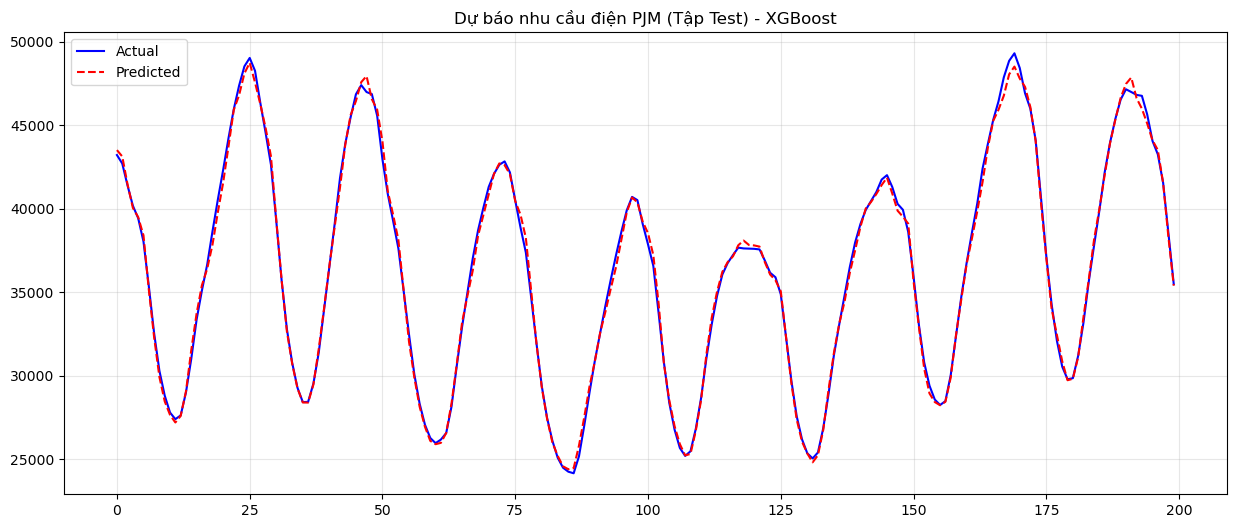

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test.values[-200:], label="Actual", color="blue")
plt.plot(y_pred[-200:], label="Predicted", color="red", linestyle="--")
plt.title("Dự báo nhu cầu điện PJM (Tập Test) - XGBoost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

XGBoost dự báo bám theo xu hướng và chu kỳ rõ ràng. Sai số thường tăng ở các đoạn biến động mạnh (đỉnh phụ tải), nhưng nhìn chung mô hình ổn định và phù hợp dự báo ngắn hạn/trung hạn.

6. Feature Importance (điểm mạnh của XGBoost)

In [49]:
import pandas as pd

# Feature importance giúp giải thích biến nào ảnh hưởng mạnh đến dự báo
imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
imp.head(20)

lag_1         0.381081
lag_2         0.314837
lag_24        0.095856
hour_cos      0.086791
lag_168       0.038595
hour          0.026782
hour_sin      0.012625
lag_3         0.010755
dayofweek     0.010612
lag_12        0.005665
dow_sin       0.004646
is_weekend    0.004083
lag_6         0.003516
month         0.002282
dow_cos       0.000906
lag_72        0.000452
lag_48        0.000272
year          0.000243
dtype: float32

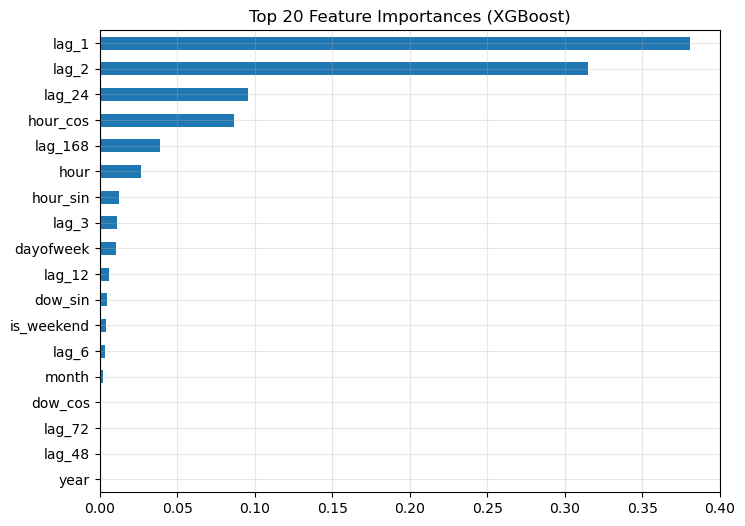

In [50]:
plt.figure(figsize=(8,6))
imp.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.grid(True, alpha=0.3)
plt.show()

Biểu đồ cho thấy các biến trễ, đặc biệt lag_1 và lag_2, có ảnh hưởng lớn nhất đến dự báo. Ngoài ra, các biến thời gian như hour và lag_24 cũng quan trọng, cho thấy nhu cầu điện có tính chu kỳ theo giờ và theo ngày.

# Dự báo nhu cầu (24h / 7 ngày / 30 ngày)

1. Chuẩn bị dữ liệu forecast

In [51]:
# Dùng df gốc (timestamp, load) để lấy đúng thời gian cuối
df_idx = df.copy()
df_idx["timestamp"] = pd.to_datetime(df_idx["timestamp"])
df_idx = df_idx.set_index("timestamp").sort_index()

last_date = df_idx.index[-1]
print("Mốc thời gian cuối:", last_date)

Mốc thời gian cuối: 2018-08-03 00:00:00


2. Hàm dự báo nhiều bước cho XGBoost (recursive): XGBoost cần “lag features”, nên dự báo theo kiểu:
dự báo 1 giờ → thêm vào lịch sử → dự báo giờ tiếp theo.

In [52]:
from datetime import timedelta

def make_feature_row(history_series, next_ts):
    """
    history_series: Series load đã có lịch sử (và sẽ được cập nhật bằng dự báo)
    next_ts: thời điểm cần dự báo (t+1, t+2,...)
    """
    row = {}

    # Feature thời gian (giúp model học chu kỳ theo giờ/ngày)
    row["hour"] = next_ts.hour
    row["dayofweek"] = next_ts.dayofweek
    row["month"] = next_ts.month
    row["year"] = next_ts.year
    row["is_weekend"] = 1 if next_ts.dayofweek >= 5 else 0

    # Cyclical encoding (biến giờ/ngày thành dạng chu kỳ)
    row["hour_sin"] = np.sin(2*np.pi*row["hour"]/24)
    row["hour_cos"] = np.cos(2*np.pi*row["hour"]/24)
    row["dow_sin"]  = np.sin(2*np.pi*row["dayofweek"]/7)
    row["dow_cos"]  = np.cos(2*np.pi*row["dayofweek"]/7)

    # Lag features: lấy các giá trị gần nhất trong lịch sử
    for lag in lags:
        row[f"lag_{lag}"] = history_series.iloc[-lag]

    # Trả về đúng thứ tự feature đã train
    return pd.DataFrame([row])[features]


def forecast_xgb(df_indexed, model, steps):
    """
    df_indexed: DataFrame có index timestamp và cột load (lịch sử)
    steps: số giờ cần dự báo (24/168/720)
    """
    hist = df_indexed["load"].copy()
    preds = []

    for _ in range(steps):
        next_ts = hist.index[-1] + timedelta(hours=1)

        # Tạo feature cho thời điểm kế tiếp dựa trên lịch sử
        X_next = make_feature_row(hist, next_ts)

        # Dự báo load
        y_next = float(model.predict(X_next)[0])

        preds.append((next_ts, y_next))

        # Cập nhật lịch sử để dự báo bước tiếp theo (recursive)
        hist.loc[next_ts] = y_next

    return pd.DataFrame(preds, columns=["timestamp","MW"]).set_index("timestamp")

3. Dự báo 24h tới

In [53]:
df_24 = forecast_xgb(df_idx, model, 24)
df_24.head()

,MW
timestamp,
2018-08-03 01:00:00,32653.878906
2018-08-03 02:00:00,30751.572266
2018-08-03 03:00:00,29420.384766
2018-08-03 04:00:00,28748.759766
2018-08-03 05:00:00,28784.910156


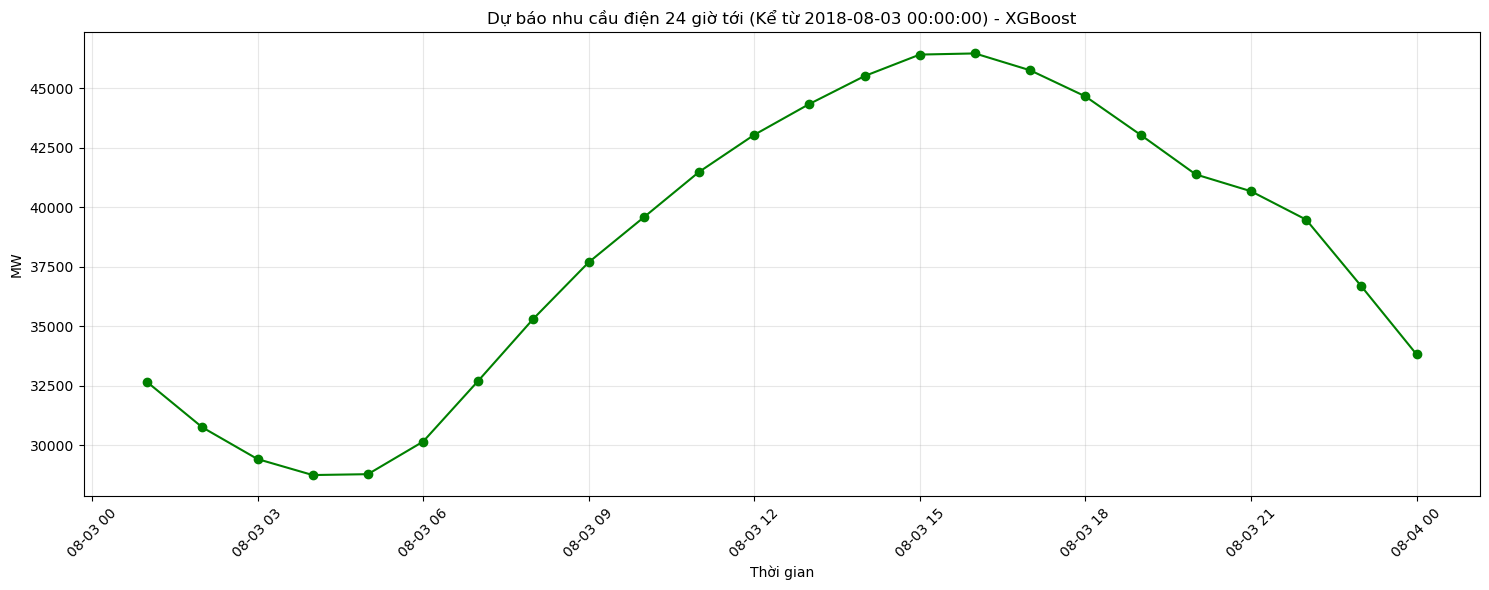

In [54]:
plt.figure(figsize=(15,6))
plt.plot(df_24.index, df_24["MW"], color="green", marker="o", linestyle="-")
plt.title(f"Dự báo nhu cầu điện 24 giờ tới (Kể từ {last_date}) - XGBoost")
plt.xlabel("Thời gian")
plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Biểu đồ dự báo cho thấy nhu cầu điện có xu hướng tăng dần vào ban ngày và đạt đỉnh vào buổi chiều, sau đó giảm dần vào ban đêm. Kết quả này phù hợp với quy luật tiêu thụ điện thực tế theo chu kỳ trong ngày.

4. Dự báo 7 ngày

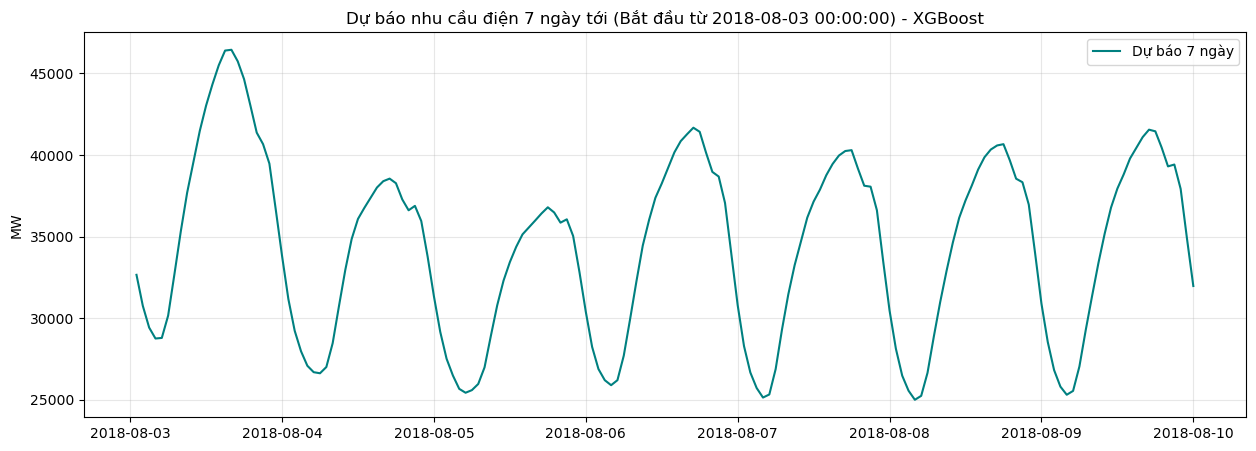

In [55]:
df_7 = forecast_xgb(df_idx, model, 168)

plt.figure(figsize=(15,5))
plt.plot(df_7.index, df_7["MW"], color="teal", label="Dự báo 7 ngày")
plt.title(f"Dự báo nhu cầu điện 7 ngày tới (Bắt đầu từ {last_date}) - XGBoost")
plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Biểu đồ dự báo 7 ngày cho thấy nhu cầu điện lặp lại theo chu kỳ ngày, với mức tiêu thụ tăng cao vào ban ngày và giảm vào ban đêm. Xu hướng dao động khá ổn định giữa các ngày, cho thấy mô hình đã học được quy luật chu kỳ của dữ liệu.

5. Dự báo 30 ngày

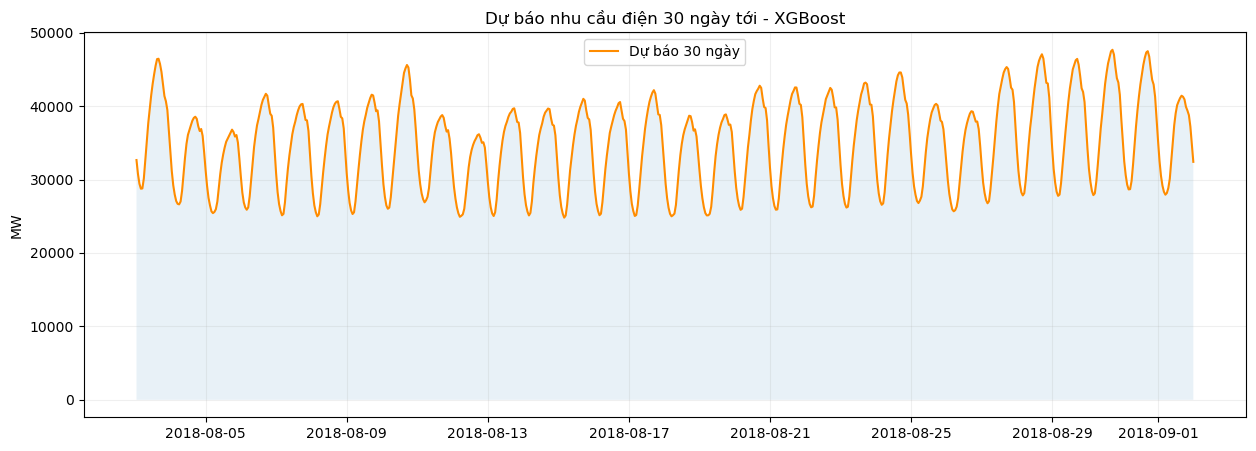

In [56]:
df_30 = forecast_xgb(df_idx, model, 720)

plt.figure(figsize=(15,5))
plt.plot(df_30.index, df_30["MW"], color="darkorange", label="Dự báo 30 ngày")
plt.fill_between(df_30.index, df_30["MW"], alpha=0.1)
plt.title("Dự báo nhu cầu điện 30 ngày tới - XGBoost")
plt.ylabel("MW")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

Nhận xét kết luận mô hình XGBoost:

XGBoost kết hợp các đặc trưng thời gian và biến trễ cho kết quả dự báo khá tốt và ổn định. Mô hình có ưu điểm về tốc độ huấn luyện nhanh và khả năng giải thích thông qua Feature Importance. Tuy nhiên, so với mô hình LSTM, XGBoost có thể hạn chế hơn trong việc học các quan hệ phụ thuộc dài hạn trong chuỗi thời gian. Vì vậy, XGBoost phù hợp để sử dụng như một mô hình so sánh và hỗ trợ đánh giá hiệu quả trong bài toán dự báo nhu cầu điện



# Lưu mô hình để dùng cho hệ thống

In [58]:
import joblib

model_path = "../artifacts/model.pkl"
joblib.dump(model, model_path)

print("Model saved:", model_path)

Model saved: ../artifacts/model.pkl


# Lưu cấu hình feature

In [59]:
import json

feature_config = {
    "target": "PJME_MW",
    "features": list(X_train.columns)
}

with open("../artifacts/feature_config.json", "w") as f:
    json.dump(feature_config, f)

# Tạo file dự báo cho hệ thống

In [60]:
forecast_df = pd.DataFrame({
    "Datetime": y_test.index,
    "Actual": y_test,
    "Predicted": y_pred
})

forecast_df.to_csv("../outputs/forecasts/test_forecast.csv", index=False)